In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

c:\Users\M.UMAIR\Desktop\mlops\Google_Stock_Price_Forcasting\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
file_path = "GOOG.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "henryshan/google-stock-price",
  file_path,
)

print("First 5 records:", df.head())

C:\Users\M.UMAIR\AppData\Local\Temp\ipykernel_10580\2136892351.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 334k/334k [00:00<00:00, 358kB/s]

First 5 records:          Date      Open      High       Low     Close  Adj Close     Volume
0  2004-08-19  2.490664  2.591785  2.390042  2.499133   2.499133  897427216
1  2004-08-20  2.515820  2.716817  2.503118  2.697639   2.697639  458857488
2  2004-08-23  2.758411  2.826406  2.716070  2.724787   2.724787  366857939
3  2004-08-24  2.770615  2.779581  2.579581  2.611960   2.611960  306396159
4  2004-08-25  2.614201  2.689918  2.587302  2.640104   2.640104  184645512


In [5]:
df.shape

(4858, 7)

In [6]:
df.head(5)['Date'].values

array(['2004-08-19', '2004-08-20', '2004-08-23', '2004-08-24',
       '2004-08-25'], dtype=object)

In [7]:
df.tail(5)

,Date,Open,High,Low,Close,Adj Close,Volume
4853,2023-11-29,138.985001,139.669998,136.294998,136.399994,136.399994,21014700
4854,2023-11-30,136.399994,136.960007,132.789993,133.919998,133.919998,29913500
4855,2023-12-01,133.320007,133.500000,132.151993,133.320007,133.320007,24258400
4856,2023-12-04,131.294006,131.449997,129.399994,130.630005,130.630005,24117100
4857,2023-12-05,130.369995,133.539993,129.729996,132.389999,132.389999,19216500


In [8]:
df.shape

(4858, 7)

In [9]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [10]:
df['Date']=pd.to_datetime(df['Date'])

In [11]:
df.dtypes

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

In [12]:
numeric_cols=df.dtypes[df.dtypes!='datetime64[ns]']

In [13]:
numeric_cols=numeric_cols.index

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

<Figure size 1800x1000 with 0 Axes>

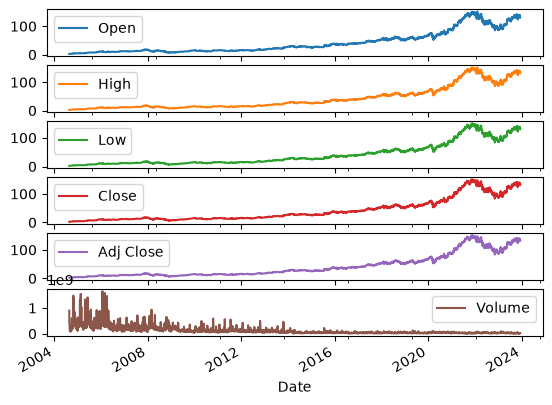

In [14]:
# Create a figure that is 10 inches wide and 6 inches tall
plt.figure(figsize=(18,10))
df.set_index('Date').plot(subplots=True)

In [15]:
df[numeric_cols]

,Open,High,Low,Close,Adj Close,Volume
0,2.490664,2.591785,2.390042,2.499133,2.499133,897427216
1,2.515820,2.716817,2.503118,2.697639,2.697639,458857488
2,2.758411,2.826406,2.716070,2.724787,2.724787,366857939
3,2.770615,2.779581,2.579581,2.611960,2.611960,306396159
4,2.614201,2.689918,2.587302,2.640104,2.640104,184645512
...,...,...,...,...,...,...
4853,138.985001,139.669998,136.294998,136.399994,136.399994,21014700
4854,136.399994,136.960007,132.789993,133.919998,133.919998,29913500
4855,133.320007,133.500000,132.151993,133.320007,133.320007,24258400
4856,131.294006,131.449997,129.399994,130.630005,130.630005,24117100


In [14]:
df[numeric_cols].corr()

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.999903,0.999896,0.999774,0.999774,-0.471746
High,0.999903,1.000000,0.999875,0.999894,0.999894,-0.470766
Low,0.999896,0.999875,1.000000,0.999904,0.999904,-0.473027
Close,0.999774,0.999894,0.999904,1.000000,1.000000,-0.472017
Adj Close,0.999774,0.999894,0.999904,1.000000,1.000000,-0.472017
Volume,-0.471746,-0.470766,-0.473027,-0.472017,-0.472017,1.000000


<Axes: >

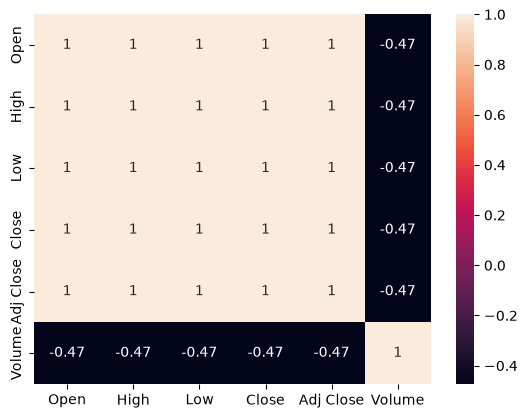

In [16]:
sns.heatmap(df[numeric_cols].corr(),annot=True)

<Axes: xlabel='Date'>

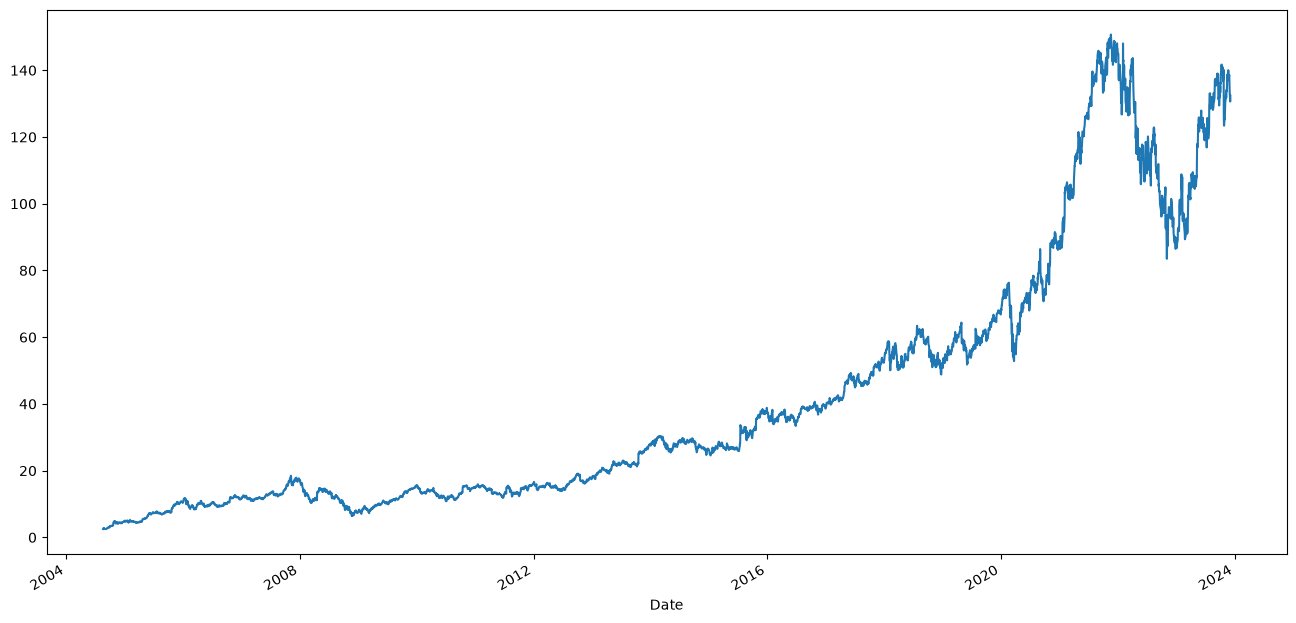

In [18]:
plt.figure(figsize=(16, 8))
df.set_index('Date')['Close'].plot()

## Exploring Close Price Pattern  By Smooting their pattern

In [19]:
df['close:smc:30']=df['Close'].rolling(window=30,min_periods=1).mean()

#### SMC with 30 Window

<Axes: >

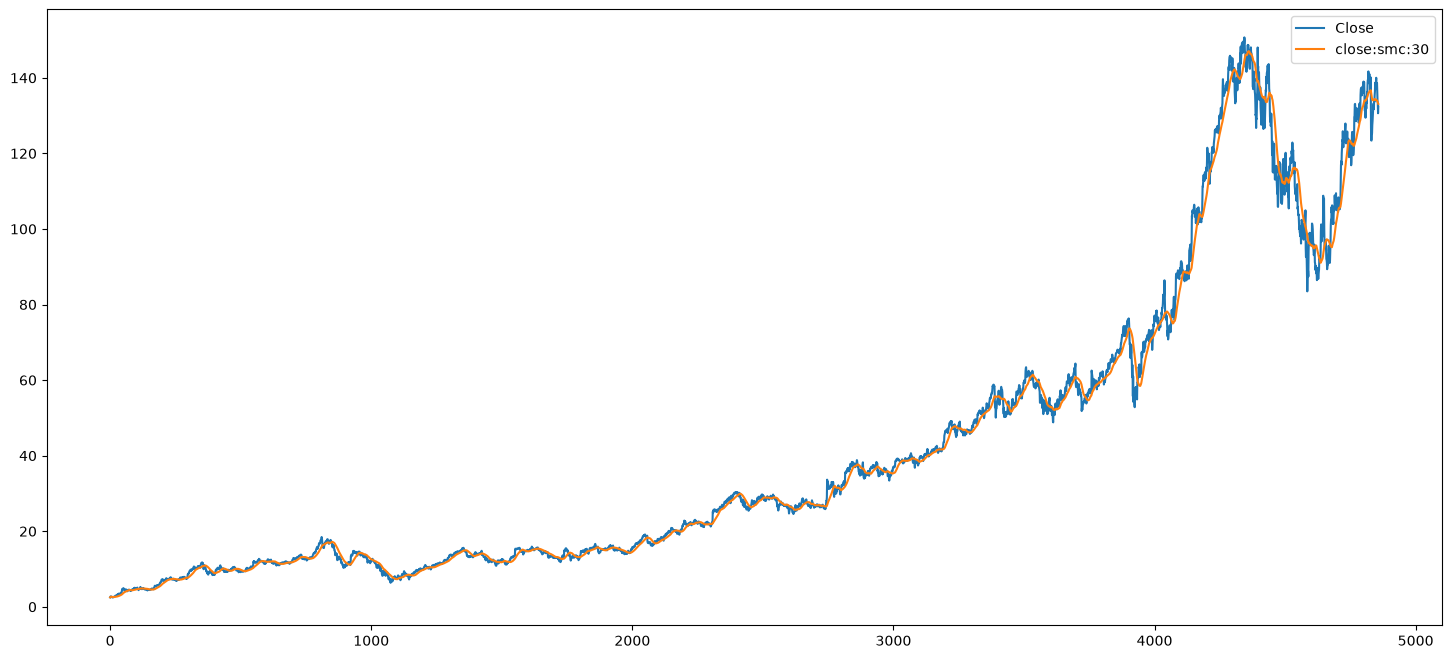

In [20]:
df[['Close','close:smc:30']].plot(figsize=(18, 8))

#### SMC with 50 Window

In [21]:
df['close:smc:50']=df['Close'].rolling(window=50,min_periods=1).mean()

<Axes: >

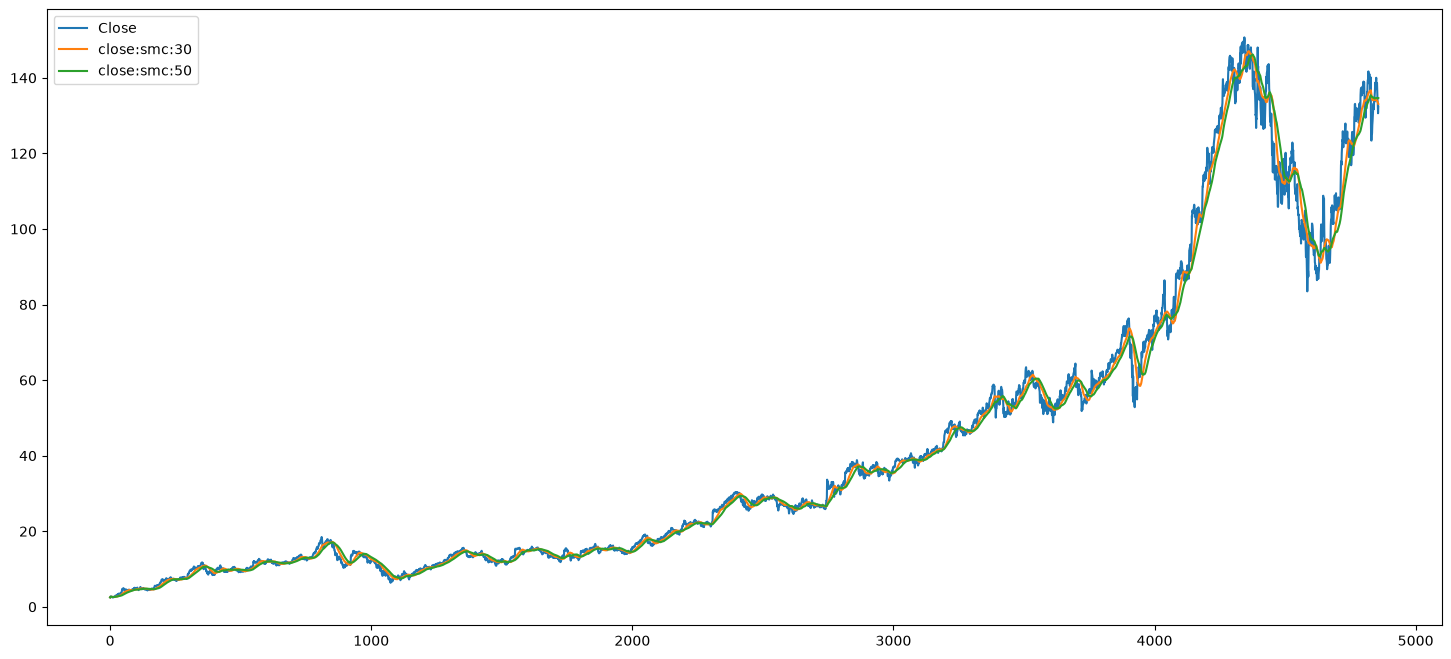

In [22]:

df[['Close','close:smc:30','close:smc:50']].plot(figsize=(18, 8))

In [23]:
df['CLOSE:EWMA:0.3'] = df['Close'].ewm(alpha=0.3, adjust=False).mean()


<Axes: >

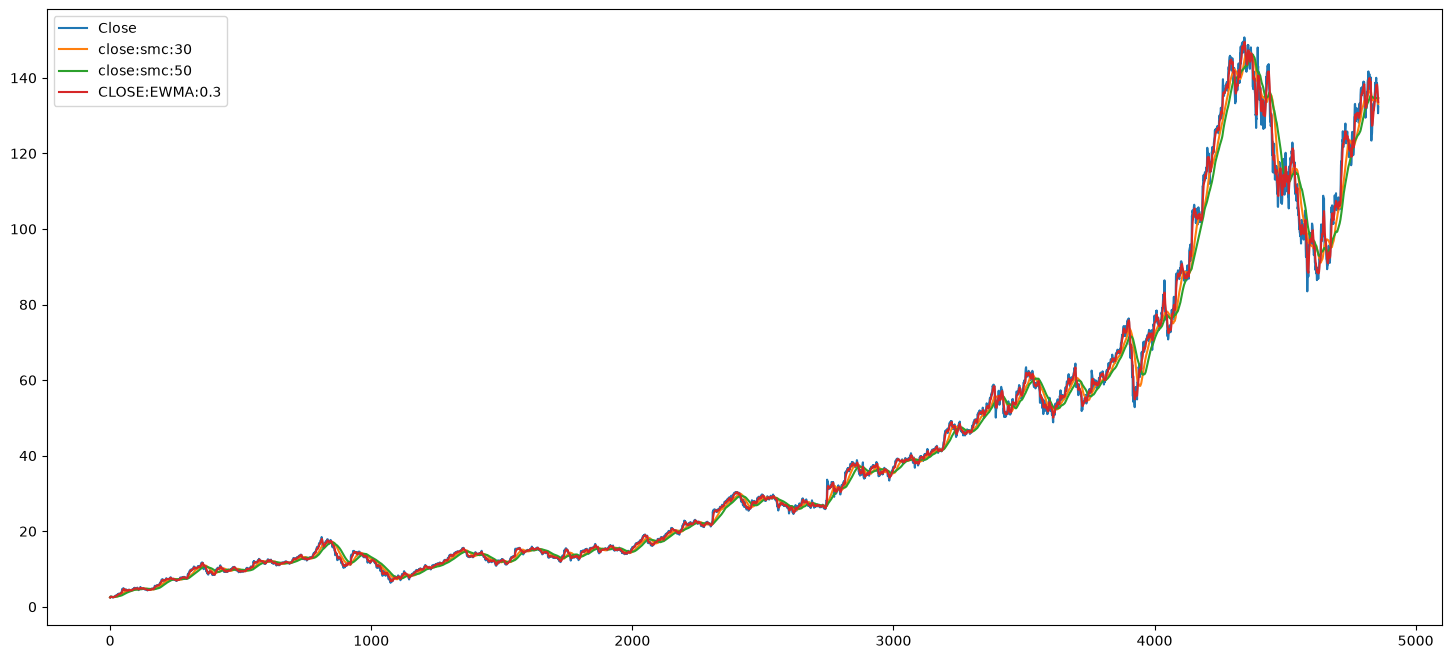

In [24]:
df[['Close','close:smc:30','close:smc:50','CLOSE:EWMA:0.3']].plot(figsize=(18, 8))

In [25]:
df['CLOSE:EWMA:0.5'] = df['Close'].ewm(alpha=0.5, adjust=False).mean()


<Axes: >

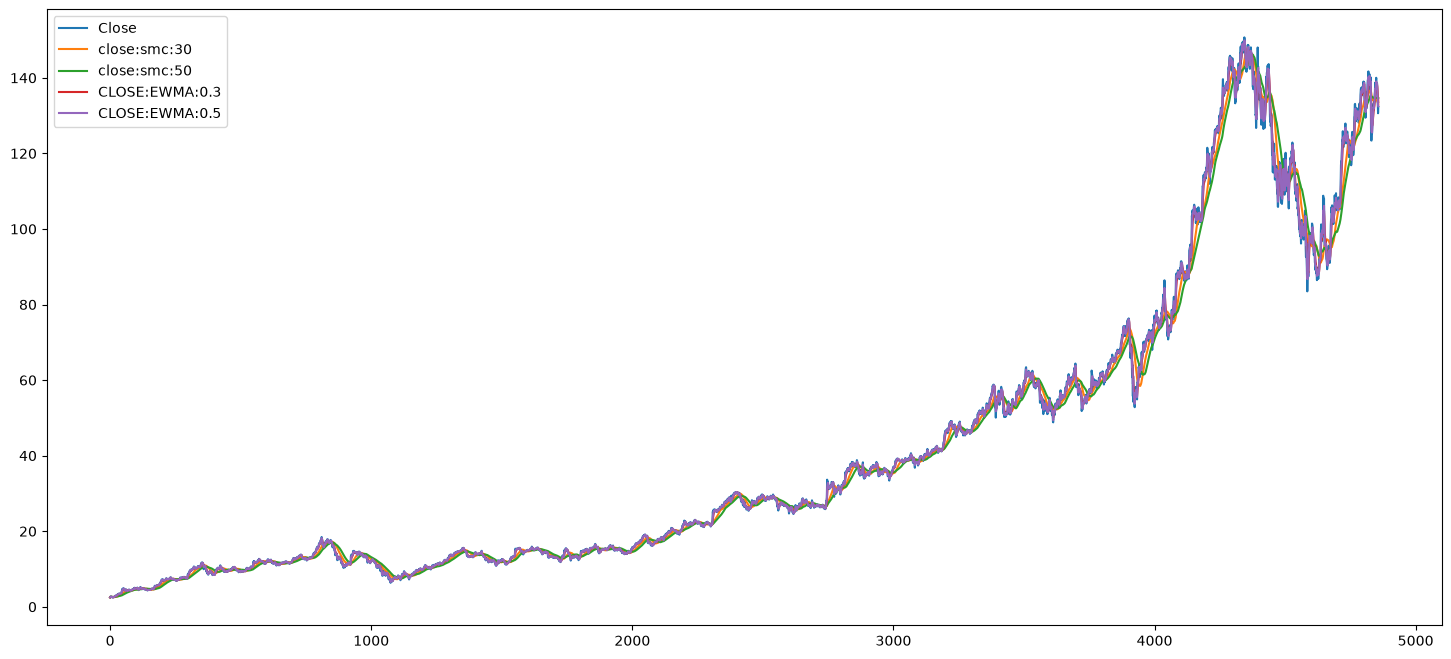

In [26]:
df[['Close','close:smc:30','close:smc:50','CLOSE:EWMA:0.3','CLOSE:EWMA:0.5']].plot(figsize=(18, 8))

## Let's Check the Outlier

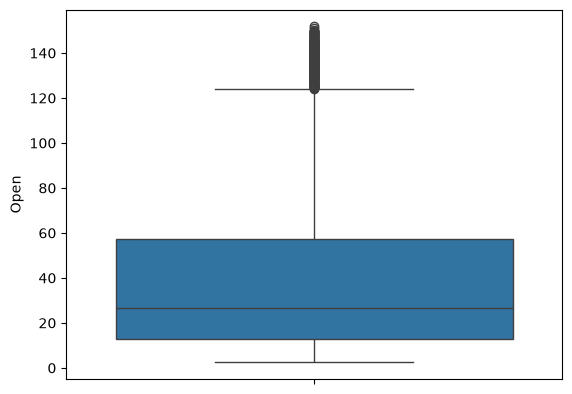

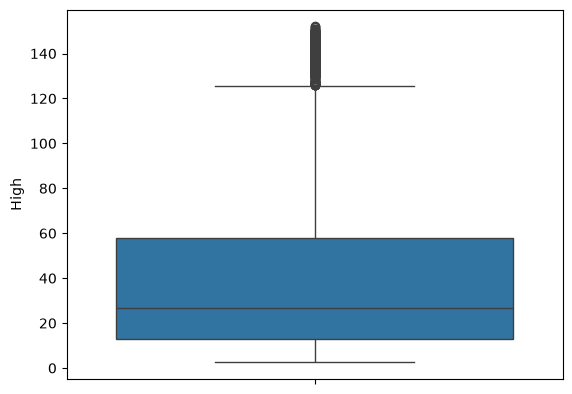

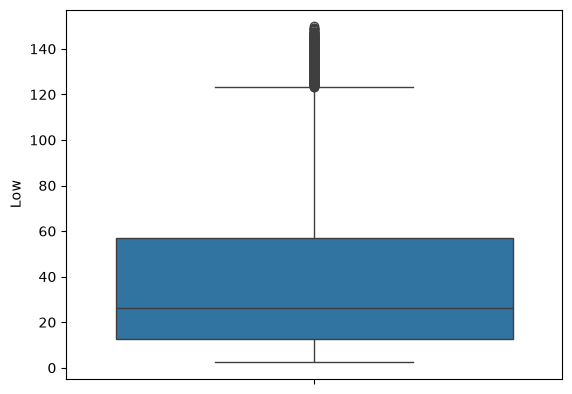

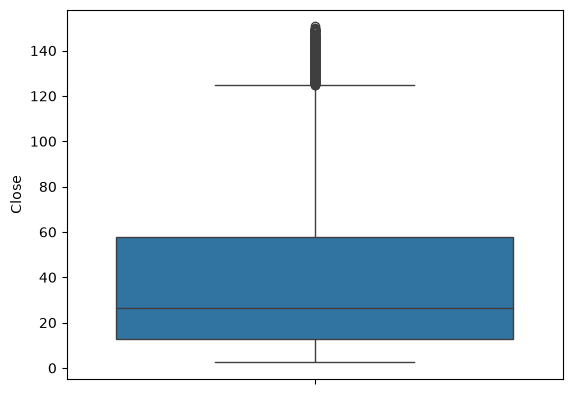

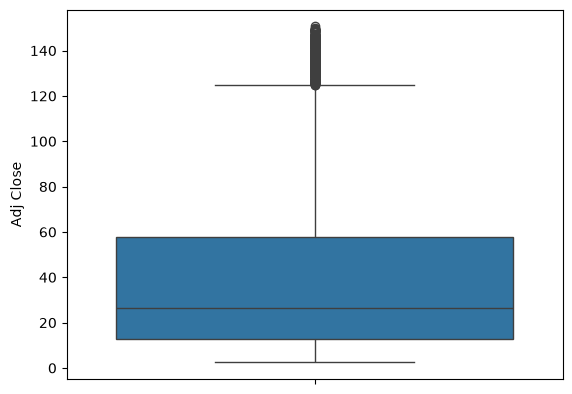

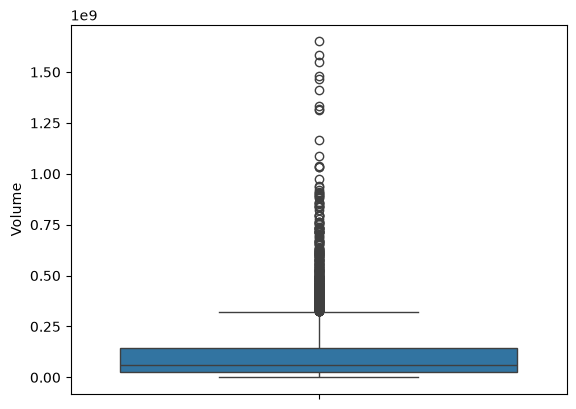

In [27]:
for col in numeric_cols:
    sns.boxplot(df[col])
    plt.show()

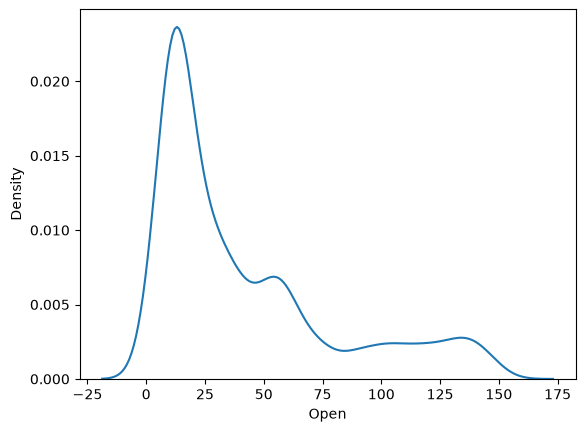

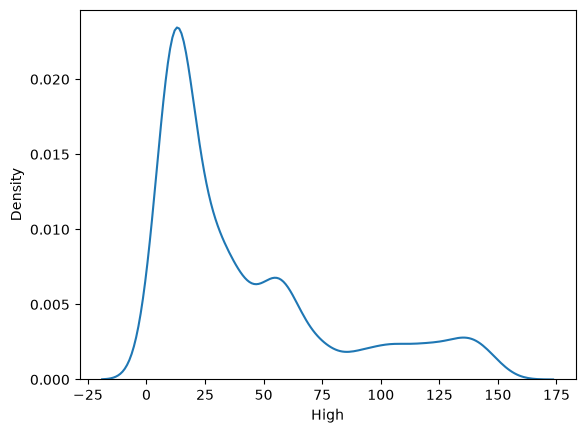

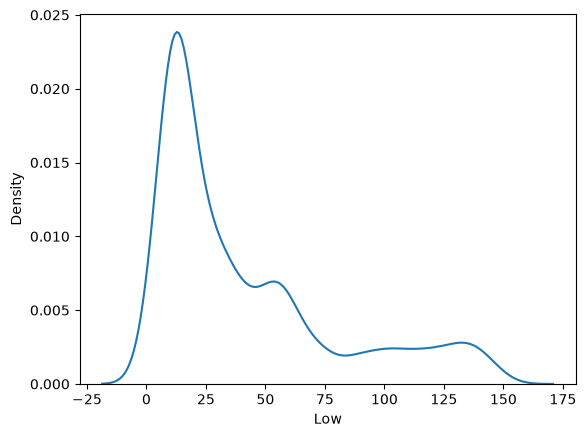

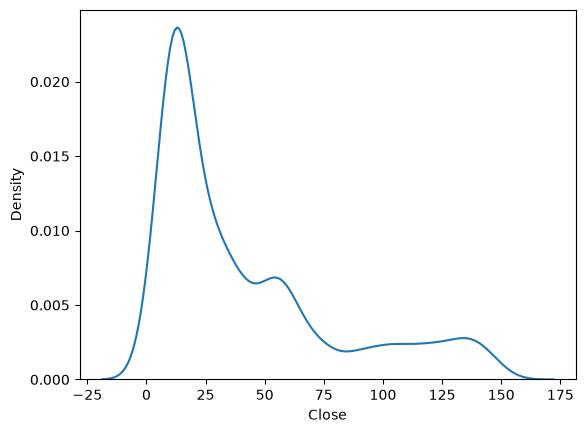

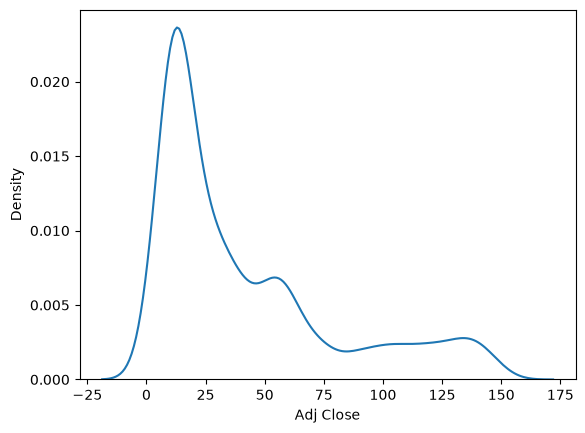

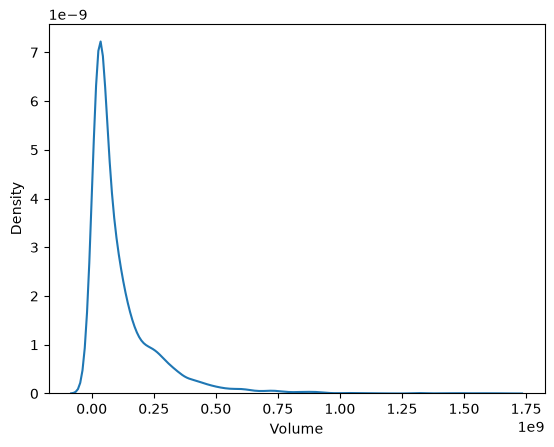

In [28]:
for col in numeric_cols:
    sns.kdeplot(df[col])
    plt.show()

## Resampling

In [29]:
df.set_index('Date',inplace=True)

<Axes: xlabel='Date'>

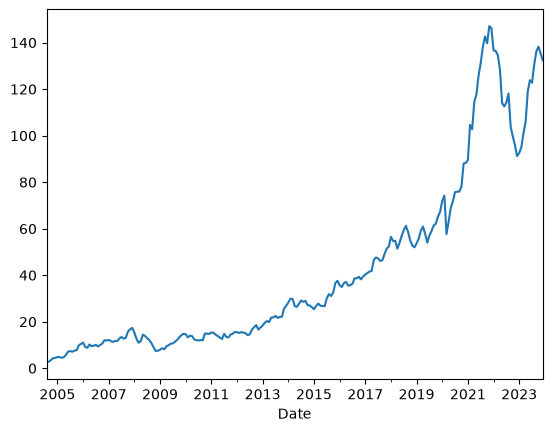

In [30]:
df['Close'].resample('ME').median().plot()

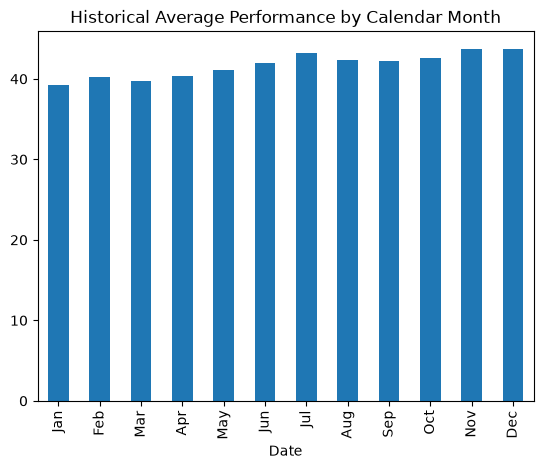

In [31]:
# Group by the month number (1 = Jan, 12 = Dec) and calculate the average median price
seasonal_pattern = df['Close'].resample('ME').median().groupby(lambda x: x.month).mean()

# Plot it to see historical monthly performance
seasonal_pattern.plot(kind='bar')
import matplotlib.pyplot as plt
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Historical Average Performance by Calendar Month')
plt.show()

### As we have analyzed visually we founded that series is not stationary,
### but for practice purpose we still analyze it seasonal decomposition and adf test ##

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [31]:
df=df.sort_index()

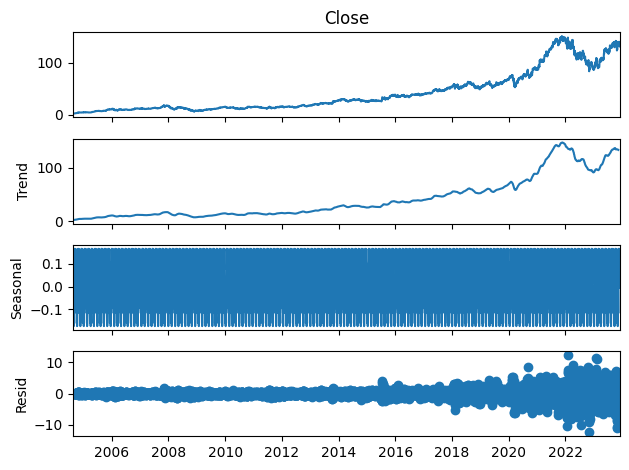

In [32]:
decomposition = seasonal_decompose(
    df['Close'],
    model='additive',
    period=30
)

fig = decomposition.plot()
plt.show()

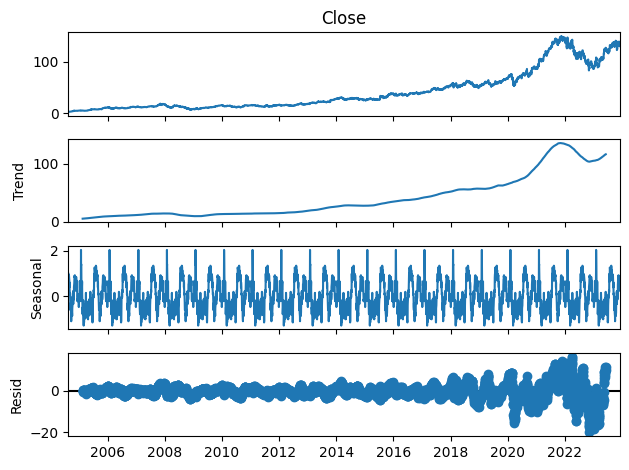

In [33]:
result=seasonal_decompose(
    df['Close'],
    model='additive',      # or 'multiplicative'
    period=252
)
fig = result.plot()
plt.show()

In [34]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for k, v in result[4].items():
    print(k, ":", v)

ADF Statistic: 0.836731367496246
p-value: 0.9922065303390484
Critical Values:
1% : -3.431705735941445
5% : -2.862139083930853
10% : -2.567088893919505


### series is not Stationary, need to make the series stationary 

In [35]:
stationary_series = df['Close'] - df['Close'].shift(1)

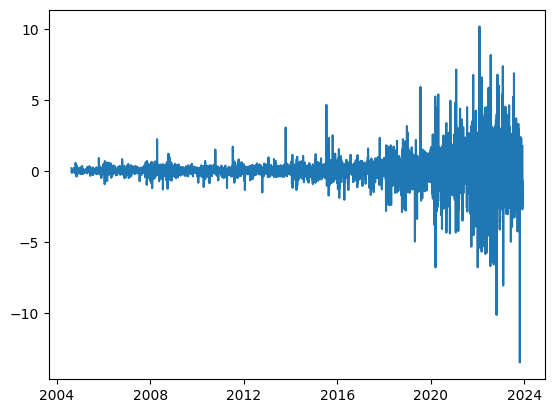

In [36]:
plt.plot(stationary_series)

### Now Series is approximate Stationary

### Let's checking which model will be used and how many lags are required 

In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

series = df['Close']

<Figure size 1200x500 with 0 Axes>

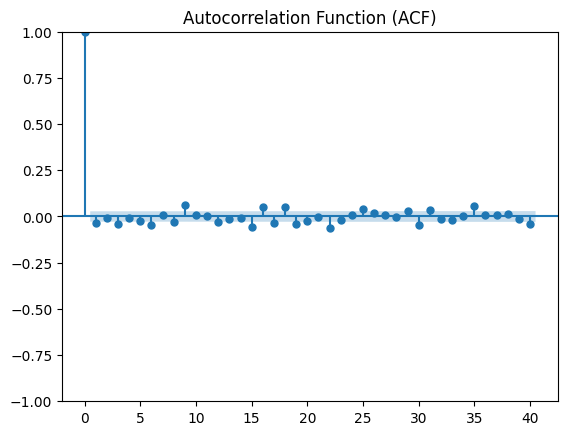

In [38]:
plt.figure(figsize=(12,5))
plot_acf(stationary_series.dropna(), lags=40)
plt.title("Autocorrelation Function (ACF)")
plt.show()

<Figure size 1200x500 with 0 Axes>

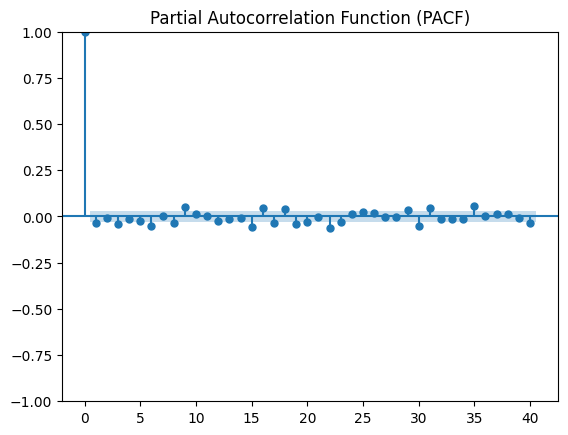

In [39]:

plt.figure(figsize=(12,5))
plot_pacf(stationary_series.dropna(), lags=40, method='ols')
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

### Using AIC and BIC for Find Best P,D,Q value

In [40]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

In [41]:
warnings.filterwarnings("ignore")

In [ ]:
best_aic = float("inf")
best_order = None

for p in range(0, 4):
    for d in range(0, 3):
        for q in range(0, 4):
            try:
                model = ARIMA(stationary_series, order=(p,d,q))
                result = model.fit()

                if result.aic < best_aic:
                    best_aic = result.aic
                    best_order = (p,d,q)

                print((p,d,q), "AIC:", result.aic)

            except:
                continue

print("\nBest ARIMA order:", best_order)
print("Best AIC:", best_aic)

## Let's Building Model For Univaraite Time Series Problem

### splitting into Train and Test

In [42]:
series=df['Close']

In [43]:
train=series[:int(len(series)*0.8)]

In [44]:
test=series[int(len(series)*0.8):]

In [45]:
print('train length ',len(train))
print('test length ',len(test))
print('total length ',len(train)+len(test))
print('total length df',len(df))

train length  3886
test length  972
total length  4858
total length df 4858


In [46]:
model=ARIMA(train,order=(3, 0, 2))

In [47]:
model_fit=model.fit()

In [48]:
test_pred = model_fit.predict(start=len(train), end=len(df)-1)

In [49]:
train_pred = model_fit.predict(start=0, end=len(train)-1)

In [50]:
test_pred.shape

(972,)

In [51]:
train_pred.shape

(3886,)

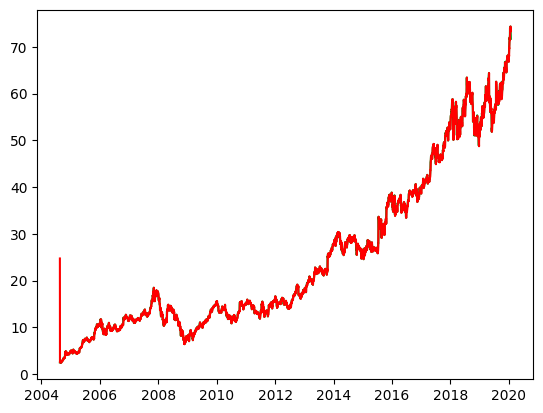

In [52]:
plt.plot(train.index, train, label="Actual Train",color='green')
plt.plot(train.index, train_pred, label="Train prediction",color='red')


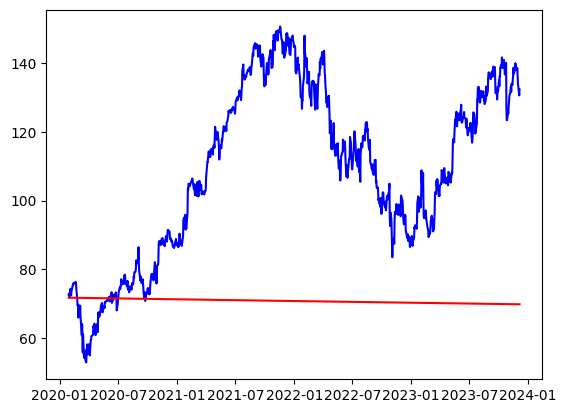

In [53]:
plt.plot(test.index, test, label="Test", color="blue")
plt.plot(test.index, test_pred, label="Test Prediction", color="red")

### Preparing Data For LSTM

In [34]:
df.reset_index(inplace=True)

In [35]:
series=df['Close'].values

In [36]:
series.shape

(4858,)

In [182]:
def get_data_in_time_steps(last_n_features):
    X=[]
    y=[]
    date=[]
    for i in range((df['Close'].shape[0]-last_n_features)-1):
        X.append(series[i:i+last_n_features])
        y.append(series[i+last_n_features])
        date.append(df.iloc[i+last_n_features]['Date'])
    X=np.array(X)
    y=np.array(y)
    date=np.array(date)
    
    return X,y,date

In [183]:
X,y,date=get_data_in_time_steps(20)

In [184]:
X.shape

(4837, 20)

In [185]:
y.shape

(4837,)

In [186]:
date.shape

(4837,)

### Splitting the Data

In [187]:
def split_data(train_size,X,y,date):
    X_train = X[:train_size]
    train_date =date[:train_size]
    X_test = X[train_size:]
    test_date =date[train_size:]
    
    y_train = y[:train_size]
    y_test = y[train_size:]

    return X_train,X_test,train_date,test_date,y_train,y_test

In [188]:
train_size = int(len(X) * 0.8)
X_train,X_test,train_date,test_date,y_train,y_test=split_data(train_size,X,y,date)

In [189]:
X_train.shape

(3869, 20)

In [190]:
y_train.shape

(3869,)

In [191]:
X_test.shape

(968, 20)

In [192]:
X_train.reshape(-1,1)

array([[ 2.499133],
       [ 2.697639],
       [ 2.724787],
       ...,
       [71.695   ],
       [72.627998],
       [72.931503]], shape=(77380, 1))

### Let Normalize the Data

In [151]:
import torch
from torch import nn
from torch.utils.data import Dataset,DataLoader
from sklearn.preprocessing import MinMaxScaler
import torch.optim as optim

In [193]:
def transform_X(X_train,X_test):
    transformer=MinMaxScaler()
    transformer.fit(X_train.reshape(-1,1))
    X_train=transformer.transform(X_train.reshape(-1,1)).reshape(X_train.shape)
    X_test=transformer.transform(X_test.reshape(-1,1)).reshape(X_test.shape)
    return transformer,X_train,X_test
    

In [194]:
def transform_Y(y_train,y_test):
    y_transformer = MinMaxScaler()
    y_transformer.fit(y_train.reshape(-1,1))
    y_train=y_transformer.transform(y_train.reshape(-1,1))
    y_test=y_transformer.transform(y_test.reshape(-1,1))
    return y_transformer,y_train,y_test
    

In [195]:
transformer,X_train,X_test=transform_X(X_train,X_test)

In [196]:
y_transformer,y_train,y_test=transform_Y(y_train,y_test)

### Let's Reshape and Convert into Tensor

In [197]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [198]:
def convert_into_tensor_and_reshape(X_train,X_test,y_train,y_test):
    X_train=torch.tensor(X_train,dtype=torch.float32)
    X_test=torch.tensor(X_test,dtype=torch.float32)
    y_train=torch.tensor(y_train,dtype=torch.float32)
    y_test=torch.tensor(y_test,dtype=torch.float32)
    X_train=X_train.unsqueeze(-1)
    X_test=X_test.unsqueeze(-1)

    X_train=X_train.to(device)
    X_test=X_test.to(device)
    
    y_train=y_train.to(device)
    y_test=y_test.to(device)

    return X_train,X_test,y_train,y_test

## Lets Apply Hyperparameter tunning using Optuna

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import optuna

In [199]:
X_train,X_test,y_train,y_test=convert_into_tensor_and_reshape(X_train,X_test,y_train,y_test)

In [159]:
class MyDataset(Dataset):
    def __init__(self, features, target):
        self.features = features
        self.target = target

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.target[index]
        

In [200]:
train_dataset=MyDataset(X_train,y_train)
test_dataset=MyDataset(X_test,y_test)

In [335]:
class LSTMModel(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        lstm_layers,
        dense_layers,
        dense_units,
        activation,
        dropout
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=lstm_layers,
            batch_first=True
        )

        layers = []

        in_features = hidden_size

        activations = {
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "leakyrelu": nn.LeakyReLU()
        }

        for i in range(dense_layers):

            layers.append(nn.Linear(in_features, dense_units[i]))
            layers.append(activations[activation])
            layers.append(nn.Dropout(dropout))

            in_features = dense_units[i]

        layers.append(nn.Linear(in_features, 1))

        self.fc = nn.Sequential(*layers)

    def forward(self, x):

        x, _ = self.lstm(x)

        x = x[:, -1, :]

        x = self.fc(x)

        return x

In [344]:
def objective_function(trial):
    lstm_layers = trial.suggest_int( "lstm_layers", 1, 3)
    dense_layers = trial.suggest_int( "dense_layers",1,3)
    
    epochs = trial.suggest_int( "epochs",10,50)
    last_n_time_steps=trial.suggest_int('last_n_time_step',10,50)
    
    dropout = trial.suggest_float("dropout", 0, 0.5 )
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    train_ratio=trial.suggest_float('train_ratio',0.5,0.85)
    
    hidden_size = trial.suggest_categorical( "hidden_size", [32,64,128,256])
    activation = trial.suggest_categorical( "activation", ["relu","tanh","leakyrelu"])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    
    dense_units = []

    for i in range(dense_layers):

        units = trial.suggest_categorical(
            f"dense_units_{i}",
            [32,64,128,256]
        )

        dense_units.append(units)

    model=LSTMModel( 1, hidden_size, lstm_layers, dense_layers, dense_units, activation, dropout )
    model.to(device)

    X,y,date=get_data_in_time_steps(last_n_time_steps)
    train_size = int(len(X) * train_ratio)
    X_train,X_test,train_date,test_date,y_train,y_test=split_data(train_size,X,y,date)

    transformer,X_train,X_test=transform_X(X_train,X_test)
    y_transformer,y_train,y_test=transform_Y(y_train,y_test)
    X_train,X_test,y_train,y_test=convert_into_tensor_and_reshape(X_train,X_test,y_train,y_test)
    
    

    train_dataset=MyDataset(X_train,y_train)
    test_dataset=MyDataset(X_test,y_test)
    
    train_loader=DataLoader(train_dataset,batch_size=batch_size)
    test_loader=DataLoader(test_dataset,batch_size=batch_size)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # epochs = 20

    for epoch in range(epochs):
        model.train()
        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(x_batch)

            loss = criterion(predictions, y_batch)

            loss.backward()

            optimizer.step()

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for x_batch, y_batch in test_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(x_batch)

            loss = criterion(predictions, y_batch)

            val_loss += loss.item()

    return val_loss / len(test_loader)

    

In [345]:
study = optuna.create_study(direction="minimize")

[I 2026-07-04 23:23:50,870] A new study created in memory with name: no-name-ae87870e-8a01-42cc-96e9-6d0c6247e110


In [346]:
study.optimize(objective_function, n_trials=20)

[I 2026-07-04 23:24:01,056] Trial 0 finished with value: 3.780105699102084 and parameters: {'lstm_layers': 3, 'dense_layers': 1, 'epochs': 23, 'last_n_time_step': 30, 'dropout': 0.22583568108720486, 'lr': 0.006328817858022751, 'train_ratio': 0.6056213791703977, 'hidden_size': 128, 'activation': 'leakyrelu', 'batch_size': 32, 'dense_units_0': 256}. Best is trial 0 with value: 3.780105699102084.
[I 2026-07-04 23:24:05,225] Trial 1 finished with value: 0.17759744809674366 and parameters: {'lstm_layers': 1, 'dense_layers': 3, 'epochs': 23, 'last_n_time_step': 16, 'dropout': 0.44435643710021927, 'lr': 0.00015512401806778276, 'train_ratio': 0.7286814873284786, 'hidden_size': 64, 'activation': 'relu', 'batch_size': 64, 'dense_units_0': 128, 'dense_units_1': 128, 'dense_units_2': 64}. Best is trial 1 with value: 0.17759744809674366.
[I 2026-07-04 23:24:08,812] Trial 2 finished with value: 0.30854203971494615 and parameters: {'lstm_layers': 1, 'dense_layers': 1, 'epochs': 14, 'last_n_time_step'

In [347]:
print(study.best_trial.value)

print(study.best_params)

0.0020820327578500533
{'lstm_layers': 1, 'dense_layers': 2, 'epochs': 27, 'last_n_time_step': 38, 'dropout': 0.08827518889851754, 'lr': 0.00028011807504055026, 'train_ratio': 0.8438382745393745, 'hidden_size': 32, 'activation': 'relu', 'batch_size': 32, 'dense_units_0': 128, 'dense_units_1': 32}


In [348]:
for trial in study.trials:

    print("Trial :", trial.number)
    print("Value :", trial.value)
    print("Params :", trial.params)
    print("-"*50)

Trial : 0
Value : 3.780105699102084
Params : {'lstm_layers': 3, 'dense_layers': 1, 'epochs': 23, 'last_n_time_step': 30, 'dropout': 0.22583568108720486, 'lr': 0.006328817858022751, 'train_ratio': 0.6056213791703977, 'hidden_size': 128, 'activation': 'leakyrelu', 'batch_size': 32, 'dense_units_0': 256}
--------------------------------------------------
Trial : 1
Value : 0.17759744809674366
Params : {'lstm_layers': 1, 'dense_layers': 3, 'epochs': 23, 'last_n_time_step': 16, 'dropout': 0.44435643710021927, 'lr': 0.00015512401806778276, 'train_ratio': 0.7286814873284786, 'hidden_size': 64, 'activation': 'relu', 'batch_size': 64, 'dense_units_0': 128, 'dense_units_1': 128, 'dense_units_2': 64}
--------------------------------------------------
Trial : 2
Value : 0.30854203971494615
Params : {'lstm_layers': 1, 'dense_layers': 1, 'epochs': 14, 'last_n_time_step': 13, 'dropout': 0.15470003796275422, 'lr': 0.0007100242940549526, 'train_ratio': 0.6576567666473614, 'hidden_size': 32, 'activation':

### Log Experiments on Dagshubs via mlflow exteriment Tracking 

In [352]:
import mlflow

In [350]:
import dagshub
dagshub.init(repo_owner='umiii-786', repo_name='Google-Stock-Forcasting', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=c3e29687-9013-4911-991f-27b7167cb0df&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=537cfe9ef9493d7b620d435845f85f2a197f0d8cf30eb67701cdafbe4c6b13fa




Accessing as umiii-786

Initialized MLflow to track repo "umiii-786/Google-Stock-Forcasting"

Repository umiii-786/Google-Stock-Forcasting initialized!

In [353]:
import mlflow

mlflow.set_experiment("Google Stock Forecasting")

with mlflow.start_run(run_name="Optuna Study") as parent_run:

    # Log study summary
    mlflow.log_metric("best_validation_loss", study.best_value)

    mlflow.log_params(study.best_params)

    # Iterate through every trial
    for trial in study.trials:

        with mlflow.start_run(
            run_name=f"Trial_{trial.number}",
            nested=True
        ):

            # Log trial parameters
            mlflow.log_params(trial.params)

            # Log objective value
            if trial.value is not None:
                mlflow.log_metric(
                    "validation_loss",
                    trial.value
                )

            # Log trial information
            mlflow.set_tags({
                "trial_number": trial.number,
                "trial_state": str(trial.state)
            })

2026/07/04 23:32:06 INFO mlflow.tracking.fluent: Experiment with name 'Google Stock Forecasting' does not exist. Creating a new experiment.


🏃 View run Trial_0 at: https://dagshub.com/umiii-786/Google-Stock-Forcasting.mlflow/#/experiments/0/runs/e98c31ac32114d888dd8f4d4b29e6047
🧪 View experiment at: https://dagshub.com/umiii-786/Google-Stock-Forcasting.mlflow/#/experiments/0
🏃 View run Trial_1 at: https://dagshub.com/umiii-786/Google-Stock-Forcasting.mlflow/#/experiments/0/runs/aa76361be1e2449e94cccd14103f95fb
🧪 View experiment at: https://dagshub.com/umiii-786/Google-Stock-Forcasting.mlflow/#/experiments/0
🏃 View run Trial_2 at: https://dagshub.com/umiii-786/Google-Stock-Forcasting.mlflow/#/experiments/0/runs/ccc8959f9c5f4c94a7e785991d5baa8a
🧪 View experiment at: https://dagshub.com/umiii-786/Google-Stock-Forcasting.mlflow/#/experiments/0
🏃 View run Trial_3 at: https://dagshub.com/umiii-786/Google-Stock-Forcasting.mlflow/#/experiments/0/runs/edccf56ef8b34cc3871e07a64674dec2
🧪 View experiment at: https://dagshub.com/umiii-786/Google-Stock-Forcasting.mlflow/#/experiments/0
🏃 View run Trial_4 at: https://dagshub.com/umiii-786

## Let Building LSTM Model with Hyperparameter Models On Univariate Column

In [357]:
params={'lstm_layers': 1, 'dense_layers': 2, 'epochs': 27, 'last_n_time_step': 38, 'dropout': 0.08827518889851754, 'lr': 0.00028011807504055026, 
 'train_ratio': 0.8438382745393745, 'hidden_size': 32, 'activation': 'relu', 'batch_size': 32, 'dense_units_0': 128, 'dense_units_1': 32}

In [59]:
# I have not used Above Parameters Because i have tried these params, 
# but not giving the result that my own custom analyze model is giving i used that model.

In [201]:
class MYLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        # First LSTM layer
        self.lstm1 = nn.LSTM(
            input_size=1,
            hidden_size=128,
            batch_first=True,
        )

        self.fdPart = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, features):
        out, (h_n, _) = self.lstm1(features)

        out = h_n[-1]          # Last hidden state of last LSTM
        out = self.fdPart(out)

        return out

In [206]:
model = MYLSTM().to(device)

In [207]:

train_loader=DataLoader(train_dataset,batch_size=32)
test_loader=DataLoader(test_dataset,batch_size=32)

In [208]:
optimizer=optim.Adam([*model.lstm1.parameters(),*model.fdPart.parameters()], lr= 0.001)
# lr=0.001

In [209]:
lossfunc=nn.MSELoss()

In [210]:
epochs = 20

for epoch in range(epochs):
    model.train()                     # Set model to training mode
    epoch_loss = 0.0
    for batch, target in train_loader:

        # Move data to the same device as the model (CPU or GPU)
        batch, target = batch.to(device), target.to(device)
        target = target.to(device)

        # # 2. Clear old gradients from the previous step
        optimizer.zero_grad()
        
        # # 3. Forward pass
        y_pred = model(batch)
        # # 4. Compute loss (Note: PyTorch expects y_pred first, then target)
        loss = lossfunc(y_pred, target)
        
        # # 5. Backward pass (Backpropagation)
        loss.backward()
        
        # # 6. Update model weights
        optimizer.step()
        
        epoch_loss += loss.item() * batch.size(0)
   
    # Optional: Print progress after each epoch
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss / len(train_loader.dataset):.6f}")

Epoch [1/20] - Loss: 0.004718
Epoch [2/20] - Loss: 0.033775
Epoch [3/20] - Loss: 0.022601
Epoch [4/20] - Loss: 0.045371
Epoch [5/20] - Loss: 0.062351
Epoch [6/20] - Loss: 0.062632
Epoch [7/20] - Loss: 0.019572
Epoch [8/20] - Loss: 0.009401
Epoch [9/20] - Loss: 0.003809
Epoch [10/20] - Loss: 0.001391
Epoch [11/20] - Loss: 0.000961
Epoch [12/20] - Loss: 0.000805
Epoch [13/20] - Loss: 0.000627
Epoch [14/20] - Loss: 0.000446
Epoch [15/20] - Loss: 0.000355
Epoch [16/20] - Loss: 0.000303
Epoch [17/20] - Loss: 0.000281
Epoch [18/20] - Loss: 0.000266
Epoch [19/20] - Loss: 0.000251
Epoch [20/20] - Loss: 0.000239


In [211]:
X_train.shape

torch.Size([3869, 20, 1])

In [212]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()

with torch.no_grad():

    # ==========================
    # Training Prediction
    # ==========================
    y_train_pred = model(X_train)

    # Loss on scaled data
    train_loss = lossfunc(y_train_pred, y_train)
    print(f"Scaled Train Loss : {train_loss.item():.6f}")

    # Convert to numpy
    y_train_pred_np = y_train_pred.cpu().numpy()
    y_train_np = y_train.cpu().numpy()

    # Inverse scaling
    real_y_train_pred = y_transformer.inverse_transform(y_train_pred_np)
    real_y_train = y_transformer.inverse_transform(y_train_np)

    # Metrics on original scale
    train_rmse = np.sqrt(mean_squared_error(real_y_train, real_y_train_pred))
    train_mae = mean_absolute_error(real_y_train, real_y_train_pred)

    print(f"Train RMSE : {train_rmse:.4f}")
    print(f"Train MAE  : {train_mae:.4f}")


    # ==========================
    # Test Prediction
    # ==========================
    y_test_pred = model(X_test)

    # Loss on scaled data
    test_loss = lossfunc(y_test_pred, y_test)
    print(f"Scaled Test Loss : {test_loss.item():.6f}")

    # Convert to numpy
    y_test_pred_np = y_test_pred.cpu().numpy()
    y_test_np = y_test.cpu().numpy()

    # Inverse scaling
    real_y_test_pred = y_transformer.inverse_transform(y_test_pred_np)
    real_y_test = y_transformer.inverse_transform(y_test_np)

    # Metrics on original scale
    test_rmse = np.sqrt(mean_squared_error(real_y_test, real_y_test_pred))
    test_mae = mean_absolute_error(real_y_test, real_y_test_pred)

    print(f"Test RMSE : {test_rmse:.4f}")
    print(f"Test MAE  : {test_mae:.4f}")

Scaled Train Loss : 0.000235
Train RMSE : 1.0941
Train MAE  : 0.8512
Scaled Test Loss : 0.045393
Test RMSE : 15.2135
Test MAE  : 11.7679


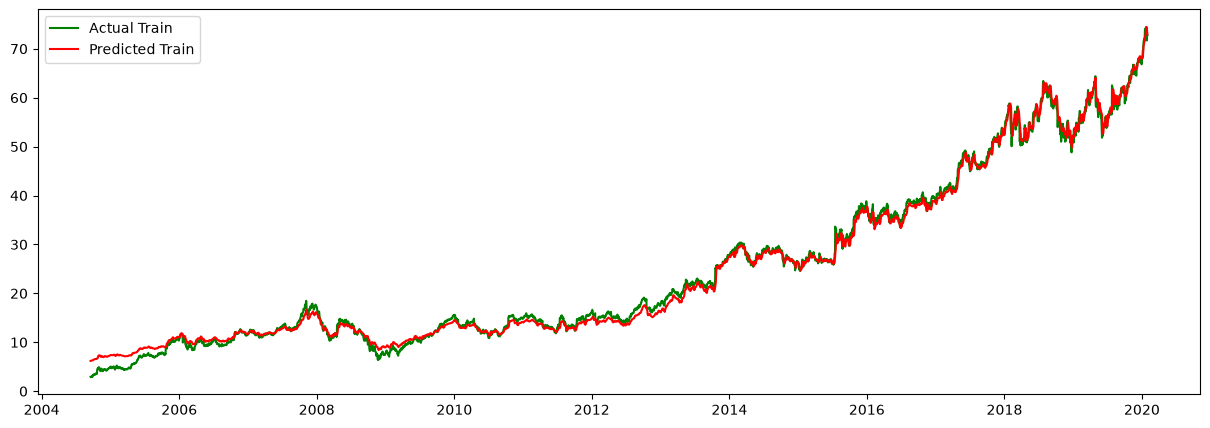

In [213]:
plt.figure(figsize=(15,5))

plt.plot(train_date, real_y_train, label="Actual Train", color="green")
plt.plot(train_date, real_y_train_pred, label="Predicted Train", color="red")

plt.legend()
plt.show()

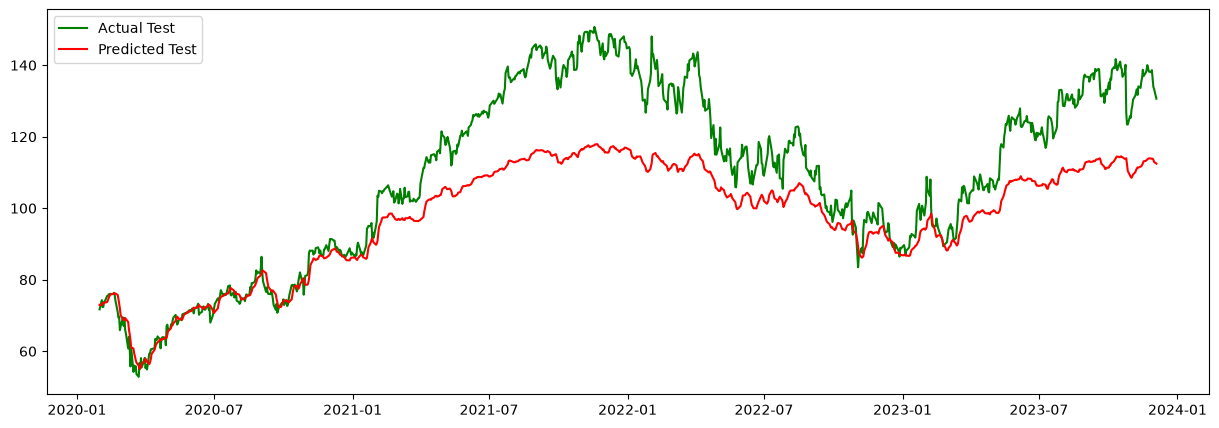

In [214]:
plt.figure(figsize=(15,5))

plt.plot(test_date, real_y_test, label="Actual Test", color="green")
plt.plot(test_date, real_y_test_pred, label="Predicted Test", color="red")

plt.legend()
plt.show()

In [215]:
last_n_features=20

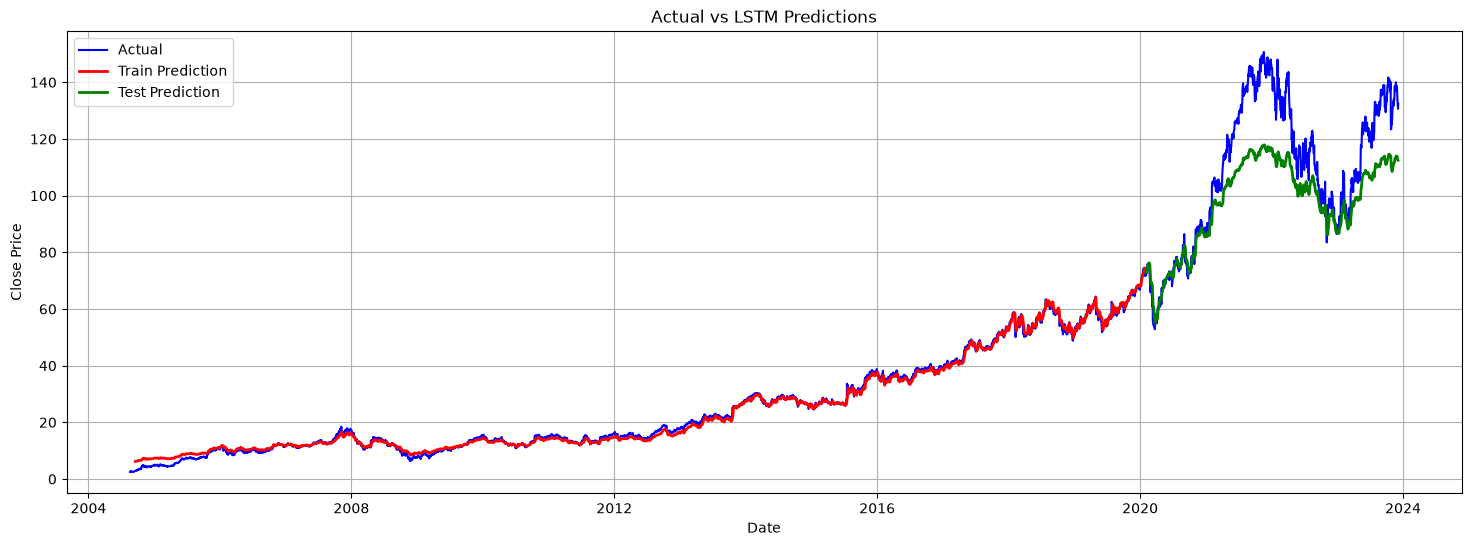

In [216]:

# Empty arrays having same length as original series
train_plot = np.full(len(series), np.nan)
test_plot = np.full(len(series), np.nan)

# -----------------------------
# Place train predictions
# -----------------------------
train_plot[last_n_features : last_n_features + len(real_y_train_pred)] = \
    real_y_train_pred.flatten()

# -----------------------------
# Place test predictions
# -----------------------------
test_plot[last_n_features + len(real_y_train_pred) :
          last_n_features + len(real_y_train_pred) + len(real_y_test_pred)] = \
    real_y_test_pred.flatten()

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(18,6))

# Actual complete series
plt.plot(df['Date'], series,
         color='blue',
         label='Actual')

# Train prediction
plt.plot(df['Date'], train_plot,
         color='red',
         linewidth=2,
         label='Train Prediction')

# Test prediction
plt.plot(df['Date'], test_plot,
         color='green',
         linewidth=2,
         label='Test Prediction')

plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Actual vs LSTM Predictions")
plt.legend()
plt.grid(True)
plt.show()

In [217]:
X_test[-1].unsqueeze(0).shape

torch.Size([1, 20, 1])

In [218]:
print(y_train.min(), y_train.max())
print(y_test.min(), y_test.max())

print(y_train_pred.min(), y_train_pred.max())
print(y_test_pred.min(), y_test_pred.max())

tensor(0.) tensor(1.)
tensor(0.6989) tensor(2.0696)
tensor(0.0459) tensor(1.0019)
tensor(0.7301) tensor(1.6102)


In [116]:
print(y_transformer.data_min_)
print(y_transformer.data_max_)

[2.926282]
[74.332497]


In [117]:
model.eval()

future_days = 10
future_predictions = []

with torch.no_grad():

    data_point = X_test[-1].unsqueeze(0) 

    for _ in range(future_days):

        result = model(data_point)           
        future_predictions.append(result.item())

        # Remove first timestep and append prediction
        data_point = torch.cat(
            (data_point[:, 1:, :], result.unsqueeze(1)),
            dim=1
        )
        

In [118]:
future_predictions=torch.tensor(future_predictions).unsqueeze(1)

In [119]:
future_predictions.shape

torch.Size([10, 1])

In [120]:
 future_predictions=y_transformer.inverse_transform(future_predictions)

In [121]:
future_predictions.shape

(10, 1)

In [122]:
y_test.shape

torch.Size([968, 1])

In [123]:
df['Date'].iloc[-1]

Timestamp('2023-12-05 00:00:00')

In [124]:
future_dates = pd.date_range(
    start=pd.to_datetime(df['Date'].iloc[-1]) + pd.Timedelta(days=1),
    periods=future_days,
    freq='B'
)

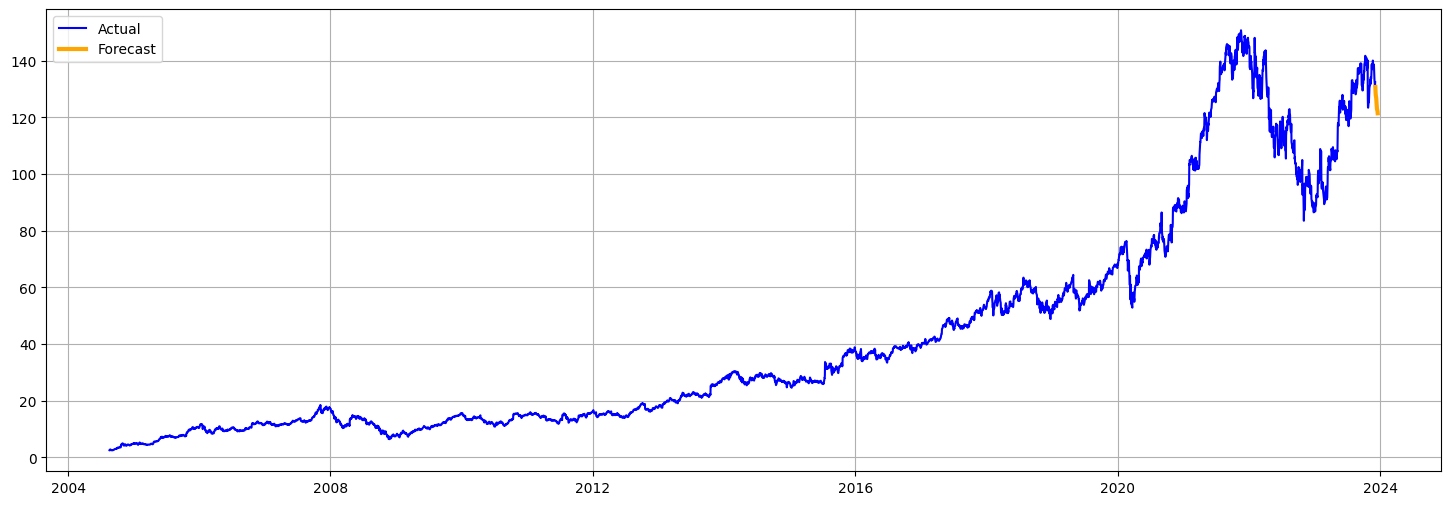

In [125]:
plt.figure(figsize=(18,6))

plt.plot(
    df['Date'],
    df['Close'],
    color='blue',
    label='Actual'
)

plt.plot(
    future_dates,
    future_predictions,
    color='orange',
    linewidth=3,
    label='Forecast'
)

plt.legend()
plt.grid(True)
plt.show()

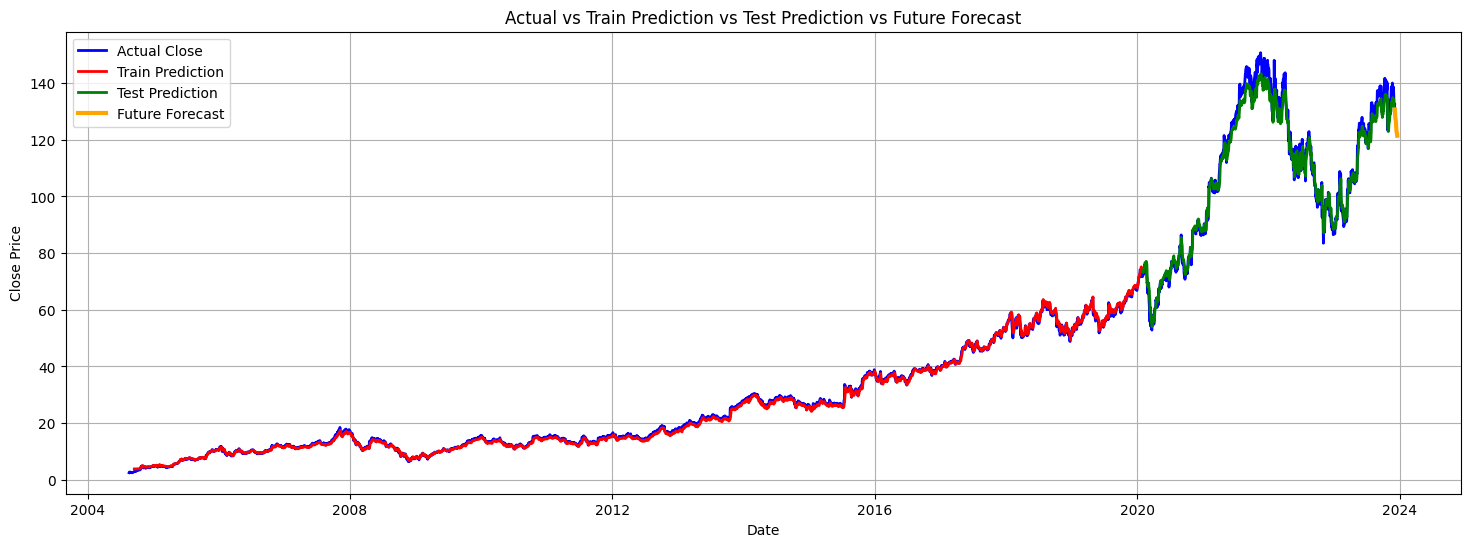

In [126]:
# Total number of observations
n = len(df)

# Empty arrays
train_plot = np.full(n, np.nan)
test_plot = np.full(n, np.nan)

# --------------------------
# Place Train Predictions
# --------------------------
train_start = last_n_features
train_end = train_start + len(real_y_train_pred)

train_plot[train_start:train_end] = real_y_train_pred.flatten()

# --------------------------
# Place Test Predictions
# --------------------------
test_start = train_end
test_end = test_start + len(real_y_test_pred)

test_plot[test_start:test_end] = real_y_test_pred.flatten()

# --------------------------
# Future Dates (Business Days)
# --------------------------
future_dates = pd.date_range(
    start=df['Date'].iloc[-1] + pd.offsets.BDay(1),
    periods=len(future_predictions),
    freq='B'
)

# --------------------------
# Plot
# --------------------------
plt.figure(figsize=(18,6))

# Actual Series
plt.plot(
    df['Date'],
    df['Close'],
    color='blue',
    linewidth=2,
    label='Actual Close'
)

# Train Prediction
plt.plot(
    df['Date'],
    train_plot,
    color='red',
    linewidth=2,
    label='Train Prediction'
)

# Test Prediction
plt.plot(
    df['Date'],
    test_plot,
    color='green',
    linewidth=2,
    label='Test Prediction'
)

# Future Forecast
plt.plot(
    future_dates,
    future_predictions.flatten(),
    color='orange',
    linewidth=3,
    label='Future Forecast'
)

plt.title("Actual vs Train Prediction vs Test Prediction vs Future Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)

plt.show()

## Practicing on Multivariate Column

### Let Building LSTM On MultiVaraite Column

In [117]:
df.drop(columns=['close:smc:30','close:smc:50','CLOSE:EWMA:0.3','CLOSE:EWMA:0.5'],axis=1,inplace=True)

In [118]:
actual_X=df.drop('Close',axis=1)

In [ ]:
actual_Y=df['Close']

In [ ]:
actual_X

In [ ]:
actual_Y=actual_Y.values

In [ ]:
last_n_features=30
X=[]
y=[]
date=[]
for i in range((df.shape[0]-last_n_features)-1):
    X.append(df.iloc[i:i+last_n_features,1:].values)
    y.append(actual_Y[(i+last_n_features)-1])
    date.append(df.iloc[i+last_n_features]['Date'])

In [ ]:
X=np.array(X)

In [ ]:
y=np.array(y)

In [ ]:
X.shape

In [ ]:
y.shape

### Let's Splitting Data

In [ ]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
train_date =date[:train_size]
X_test = X[train_size:]
test_date =date[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
X_train.shape

In [ ]:
y_train.shape

### Let's Apply Scalling 

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
x_scaler = MinMaxScaler()

X_train_shape = X_train.shape
X_test_shape = X_test.shape

X_train = x_scaler.fit_transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train_shape)

X_test = x_scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test_shape)


In [ ]:
y_scaler = MinMaxScaler()

y_train = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test = y_scaler.transform(y_test.reshape(-1, 1))

### Let's Build Model

In [ ]:
X_train=torch.tensor(X_train,dtype=torch.float32)
X_test=torch.tensor(X_test,dtype=torch.float32)
y_train=torch.tensor(y_train,dtype=torch.float32)
y_test=torch.tensor(y_test,dtype=torch.float32)

In [ ]:
X_train=X_train.to(device)
X_test=X_test.to(device)

y_train=y_train.to(device)
y_test=y_test.to(device)

In [ ]:
X_train.shape

In [ ]:
train_dataset=MyDataset(X_train,y_train)
test_dataset=MyDataset(X_test,y_test)

In [ ]:
train_loader=DataLoader(train_dataset,batch_size=64)
test_loader=DataLoader(test_dataset,batch_size=64)

In [ ]:
class MY_Stacked_LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        # First LSTM layer
        self.lstm1 = nn.LSTM(
            input_size=6,
            hidden_size=128,
            batch_first=True,
            # dropout=0.3
        )



        self.fdPart = nn.Sequential(
            nn.Linear(128, 64),
            # nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            # nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, features):
        # out, _ = self.lstm1(features)
        out, (h_n, _) = self.lstm1(features)

        out = h_n[-1]          # Last hidden state of last LSTM
        out = self.fdPart(out)

        return out

In [ ]:
model = MY_Stacked_LSTM().to(device)

In [ ]:
optimizer=optim.Adam([*model.lstm1.parameters(),*model.fdPart.parameters(),],lr=0.0001)

In [ ]:
lossfunc=nn.MSELoss()

In [ ]:
epochs = 30

for epoch in range(epochs):
    model.train()                     # Set model to training mode
    epoch_loss = 0.0
    for batch, target in train_loader:

        # Move data to the same device as the model (CPU or GPU)
        batch, target = batch.to(device), target.to(device)
        target = target.to(device)

        # # 2. Clear old gradients from the previous step
        optimizer.zero_grad()
        
        # # 3. Forward pass
        y_pred = model(batch)
        # # 4. Compute loss (Note: PyTorch expects y_pred first, then target)
        loss = lossfunc(y_pred, target)
        
        # # 5. Backward pass (Backpropagation)
        loss.backward()
        
        # # 6. Update model weights
        optimizer.step()
        
        epoch_loss += loss.item() * batch.size(0)
   
    # Optional: Print progress after each epoch
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss / len(train_loader.dataset):.6f}")

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()

with torch.no_grad():

    # ==========================
    # Training Prediction
    # ==========================
    y_train_pred = model(X_train)

    # Loss on scaled data
    train_loss = lossfunc(y_train_pred, y_train)
    print(f"Scaled Train Loss : {train_loss.item():.6f}")

    # Convert to numpy
    y_train_pred_np = y_train_pred.cpu().numpy()
    y_train_np = y_train.cpu().numpy()

    # Inverse scaling
    real_y_train_pred = y_transformer.inverse_transform(y_train_pred_np)
    real_y_train = y_transformer.inverse_transform(y_train_np)

    # Metrics on original scale
    train_rmse = np.sqrt(mean_squared_error(real_y_train, real_y_train_pred))
    train_mae = mean_absolute_error(real_y_train, real_y_train_pred)

    print(f"Train RMSE : {train_rmse:.4f}")
    print(f"Train MAE  : {train_mae:.4f}")


    # ==========================
    # Test Prediction
    # ==========================
    y_test_pred = model(X_test)

    # Loss on scaled data
    test_loss = lossfunc(y_test_pred, y_test)
    print(f"Scaled Test Loss : {test_loss.item():.6f}")

    # Convert to numpy
    y_test_pred_np = y_test_pred.cpu().numpy()
    y_test_np = y_test.cpu().numpy()

    # Inverse scaling
    real_y_test_pred = y_transformer.inverse_transform(y_test_pred_np)
    real_y_test = y_transformer.inverse_transform(y_test_np)

    # Metrics on original scale
    test_rmse = np.sqrt(mean_squared_error(real_y_test, real_y_test_pred))
    test_mae = mean_absolute_error(real_y_test, real_y_test_pred)

    print(f"Test RMSE : {test_rmse:.4f}")
    print(f"Test MAE  : {test_mae:.4f}")

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(train_date, real_y_train, label="Actual Train", color="green")
plt.plot(train_date, real_y_train_pred, label="Predicted Train", color="red")

plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(test_date, real_y_test, label="Actual Test", color="green")
plt.plot(test_date, real_y_test_pred, label="Predicted Test", color="red")

plt.legend()
plt.show()